# COMP5318 Assignment 1: Rice Classification

##### Group number: 131
##### Student Xiqing Hou SID: 530744007
##### Student Emma Shan SID: 530515599  
##### Student Runda Weng SID: 540917343 
##### Student Tingyi Lu SID: 560299003

## **1. Data Pre-processing**

In [81]:
# Import all libraries
from sklearn.model_selection import StratifiedKFold

In [82]:
# Ignore future warnings
from warnings import simplefilter
simplefilter(action='ignore', category=FutureWarning)

In [83]:
# Load the rice dataset: rice-final2.csv
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('rice-final2.csv')

In [84]:
# Pre-process dataset
# -------------------------------------------------------
# 1. Filling in the missing attribute values
# -------------------------------------------------------
df.replace('?', np.nan, inplace=True)

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X = X.apply(pd.to_numeric, errors='coerce')

imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
X_imputed = imputer.fit_transform(X)

# -------------------------------------------------------
# 2. Normalising the data
# -------------------------------------------------------

scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X_imputed)

# -------------------------------------------------------
# 3. Chaning the class values
# -------------------------------------------------------

class_mapping = {'class1': 0, 'class2': 1}
y_mapped_array = y.map(class_mapping).astype(int).values

In [85]:
# Print first ten rows of pre-processed dataset to 4 decimal places as per assignment spec
# A function is provided to assist

def print_data(X, y, n_rows=10):
    """Takes a numpy data array and target and prints the first ten rows.
    
    Arguments:
        X: numpy array of shape (n_examples, n_features)
        y: numpy array of shape (n_examples)
        n_rows: numpy of rows to print
    """
    for example_num in range(n_rows):
        for feature in X[example_num]:
            print("{:.4f}".format(feature), end=",")

        if example_num == len(X)-1:
            print(y[example_num],end="")
        else:
            print(y[example_num])
            
print_data(X_normalized, y_mapped_array, n_rows=10)

0.4628,0.5406,0.5113,0.4803,0.7380,0.4699,0.1196,1
0.4900,0.5547,0.5266,0.5018,0.7319,0.4926,0.8030,1
0.6109,0.6847,0.6707,0.5409,0.8032,0.6253,0.1185,0
0.6466,0.6930,0.6677,0.5961,0.7601,0.6467,0.2669,0
0.6712,0.6233,0.4755,0.8293,0.3721,0.6803,0.4211,1
0.2634,0.2932,0.2414,0.4127,0.5521,0.2752,0.2825,1
0.8175,0.9501,0.9515,0.5925,0.9245,0.8162,0.0000,0
0.3174,0.3588,0.3601,0.3908,0.6921,0.3261,0.8510,1
0.3130,0.3050,0.2150,0.5189,0.3974,0.3159,0.4570,1
0.5120,0.5237,0.4409,0.6235,0.5460,0.5111,0.3155,1


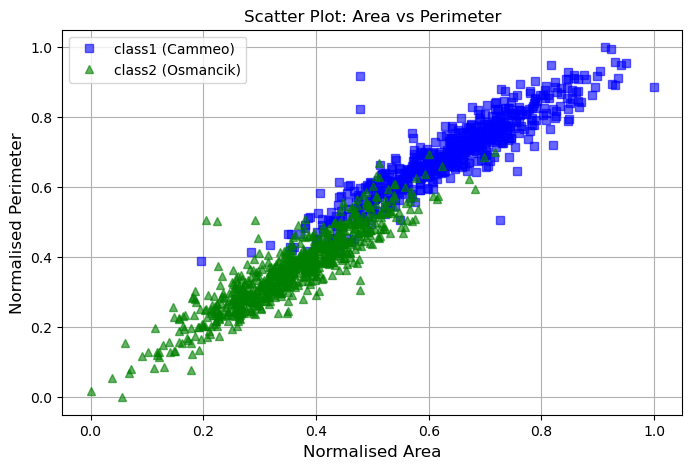

In [86]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

#  class 0 as blue squares
plt.plot(X_normalized[:, 0][y_mapped_array==0], X_normalized[:, 1][y_mapped_array==0], "bs", label="class1 (Cammeo)", alpha=0.6)
#  class 1 as green triangles
plt.plot(X_normalized[:, 0][y_mapped_array==1], X_normalized[:, 1][y_mapped_array==1], "g^", label="class2 (Osmancik)", alpha=0.6)

plt.xlabel("Normalised Area", fontsize=12)
plt.ylabel("Normalised Perimeter", fontsize=12)
plt.legend()
plt.title("Scatter Plot: Area vs Perimeter")
plt.grid(True)
plt.show()

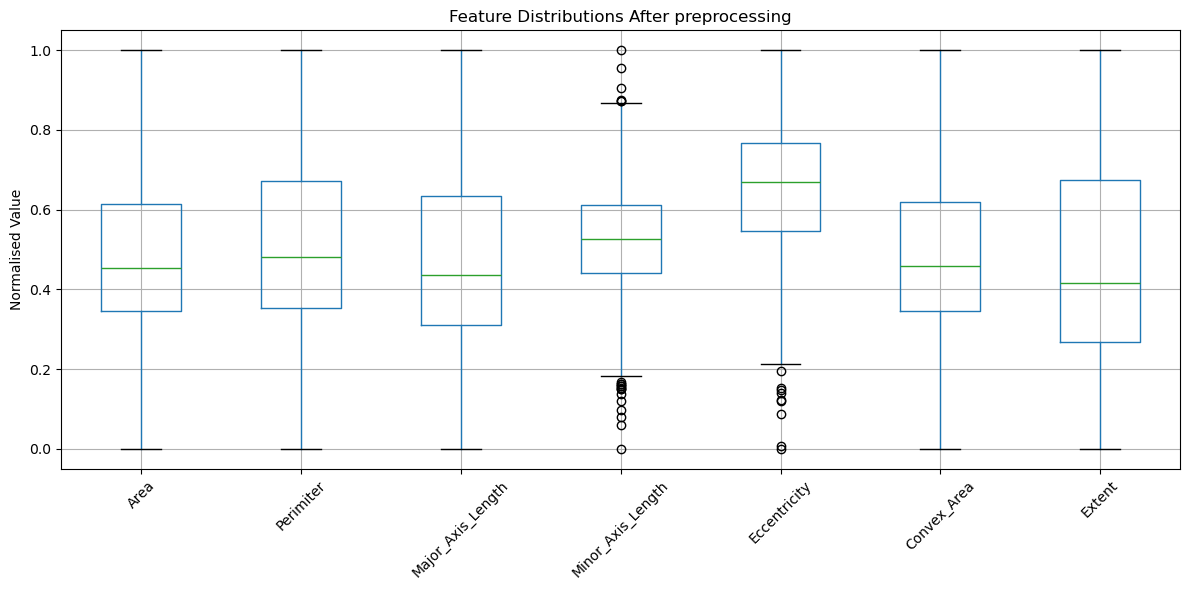

In [87]:
import matplotlib.pyplot as plt
import pandas as pd

# a dataframe from the processed feature matrix
feature_names = df.columns[:-1]
feature_df = pd.DataFrame(X_normalized, columns=feature_names)

plt.figure(figsize=(12, 6))
feature_df.boxplot(rot=45)
plt.title("Feature Distributions After preprocessing")
plt.ylabel("Normalised Value")
plt.tight_layout()
plt.show()

The boxplot above will show the spreads of all features after a min/max normalisation. The features will have been rescaled to the interval of [0,1] and be on a compariable scale for distance based methods. 

## **2. Build Classifiers**

- Part 1:  Logistic Regression, Naïve Bayes
- Part 2:  KNN, Decision Tree, Ada Boost, Gradient Boost, Random Forest, SVM

### Part 1: Cross-validation without parameter tuning

In [88]:
## Setting the 10 fold stratified cross-validation
cvKFold=StratifiedKFold(n_splits=10, shuffle=True, random_state=0)

# The stratified folds from cvKFold should be provided to the classifiers

In [89]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

log_reg = LogisticRegression(random_state=0)

log_reg_scores = cross_val_score(log_reg, X_normalized, y_mapped_array, cv=cvKFold, scoring='accuracy')

In [90]:
# Naïve Bayes
from sklearn.naive_bayes import GaussianNB

naive_bayes = GaussianNB()

nb_scores = cross_val_score(naive_bayes, X_normalized, y_mapped_array, cv=cvKFold, scoring='accuracy')


### Part 1 Results


In [91]:
# Print results for each classifier in part 1 to 4 decimal places here:
print(f"LogR average cross-validation accuracy: {log_reg_scores.mean():.4f}")
print(f"NB average cross-validation accuracy: {nb_scores.mean():.4f}")

LogR average cross-validation accuracy: 0.9386
NB average cross-validation accuracy: 0.9264


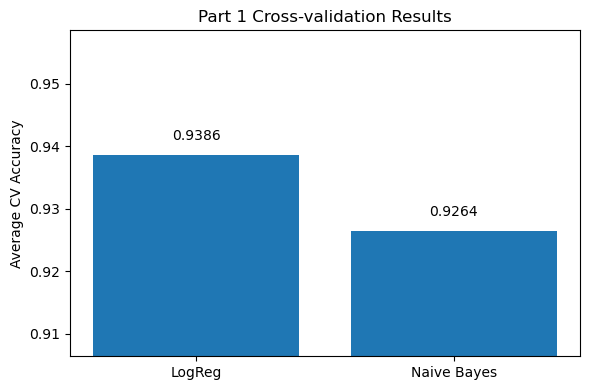

In [92]:
# classifier comparison
import matplotlib.pyplot as plt

models_part1 = ["LogReg", "Naive Bayes"]
acc_part1 = [log_reg_scores.mean(), nb_scores.mean()]

plt.figure(figsize=(6, 4))
bars = plt.bar(models_part1, acc_part1)

plt.ylabel("Average CV Accuracy")
plt.title("Part 1 Cross-validation Results")


ymin = min(acc_part1) - 0.02
ymax = max(acc_part1) + 0.02
plt.ylim(ymin, ymax)

for bar, val in zip(bars, acc_part1):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        val + 0.002,
        f"{val:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Part 2: Cross-validation with parameter tuning

In [93]:
from sklearn.model_selection import train_test_split

# -------------------------------------------------------
# Train/Test Split
# -------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_normalized,
    y_mapped_array,
    test_size=0.2,
    stratify=y_mapped_array,
    random_state=0
)

In [94]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
# KNN 
# parameters you may consider
# k = [1, 3, 5, 7]
# p = [1, 2]
param_grid_knn = {
    'n_neighbors': [1, 3, 5, 7],
    'p': [1, 2]
}

# Initialize the KNN classifier
knn = KNeighborsClassifier()

# perform Grid Search with 10-fold stratified cross-validation
grid_search_knn = GridSearchCV(estimator=knn,
                               param_grid=param_grid_knn,
                               cv=cvKFold,
                               scoring='accuracy')

# Fit the grid search model exclusively on the training data
grid_search_knn.fit(X_train, y_train)

# Retrieve the best parameters and the best cross-validation accuracy
best_k = grid_search_knn.best_params_['n_neighbors']
best_p = grid_search_knn.best_params_['p']
cv_accuracy = grid_search_knn.best_score_

best_knn_model = grid_search_knn.best_estimator_
test_accuracy = best_knn_model.score(X_test, y_test)

print(f"KNN best k: {best_k}")
print(f"KNN best p: {best_p}")
print(f"KNN cross-validation accuracy: {cv_accuracy:.4f}")
print(f"KNN test set accuracy: {test_accuracy:.4f}")

KNN best k: 7
KNN best p: 2
KNN cross-validation accuracy: 0.9375
KNN test set accuracy: 0.9250


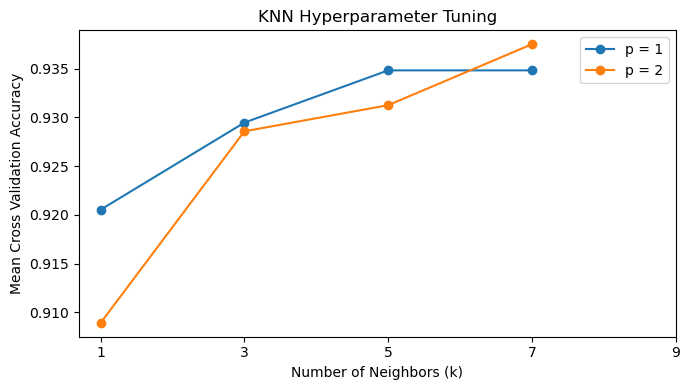

In [95]:
# graph for KNN hyperparameter tuning
import pandas as pd
import matplotlib.pyplot as plt

knn_results = pd.DataFrame(grid_search_knn.cv_results_)

p1_results = knn_results[knn_results["param_p"] == 1]
p2_results = knn_results[knn_results["param_p"] == 2]

plt.figure(figsize=(7, 4))
plt.plot(p1_results["param_n_neighbors"], p1_results["mean_test_score"], marker="o", label="p = 1")
plt.plot(p2_results["param_n_neighbors"], p2_results["mean_test_score"], marker="o", label="p = 2")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Mean Cross Validation Accuracy")
plt.title("KNN Hyperparameter Tuning")
plt.xticks([1, 3, 5, 7, 9])
plt.legend()
plt.tight_layout()
plt.show()

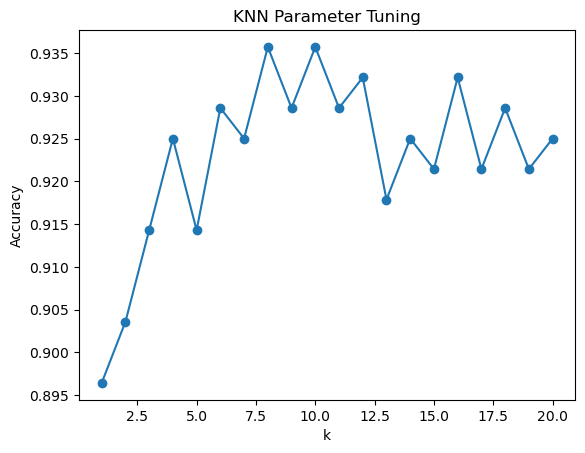

In [96]:
k_values = list(range(1, 21))
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    accuracies.append(knn.score(X_test, y_test))

plt.plot(k_values, accuracies, marker='o')
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("KNN Parameter Tuning")
plt.show()

In [97]:
from sklearn.tree import DecisionTreeClassifier
# Decision Tree 
# parameters you may consider
# max_depth = [3, 5, 7, 10]
# min_samples_split = [2, 5, 10]
# min_samples_leaf = [1, 2, 4]
param_grid_dt = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize the Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=0)

grid_search_dt = GridSearchCV(estimator=dt,
                              param_grid=param_grid_dt,
                              cv=cvKFold,
                              scoring='accuracy')

grid_search_dt.fit(X_train, y_train)

best_depth = grid_search_dt.best_params_['max_depth']
best_min_samples_split = grid_search_dt.best_params_['min_samples_split']
best_min_samples_leaf = grid_search_dt.best_params_['min_samples_leaf']
cv_accuracy_dt = grid_search_dt.best_score_

best_dt_model = grid_search_dt.best_estimator_
test_accuracy_dt = best_dt_model.score(X_test, y_test)

print(f"Decision Tree best max_depth: {best_depth}")
print(f"Decision Tree best min_samples_split: {best_min_samples_split}")
print(f"Decision Tree best min_samples_leaf: {best_min_samples_leaf}")
print(f"Decision Tree cross-validation accuracy: {cv_accuracy_dt:.4f}")
print(f"Decision Tree test set accuracy: {test_accuracy_dt:.4f}")

Decision Tree best max_depth: 3
Decision Tree best min_samples_split: 2
Decision Tree best min_samples_leaf: 1
Decision Tree cross-validation accuracy: 0.9357
Decision Tree test set accuracy: 0.9429


In [98]:
from sklearn.ensemble import AdaBoostClassifier
# Ada Boost
# parameters you may consider
# n_estimators = [50, 100, 150]
# learning_rate = [0.1, 0.2, 0.3, 0.5]

param_grid_ada = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.1, 0.2, 0.3, 0.5]
}

ada = AdaBoostClassifier(random_state=0)

grid_search_ada = GridSearchCV(estimator=ada,
                               param_grid=param_grid_ada,
                               cv=cvKFold,
                               scoring='accuracy')

grid_search_ada.fit(X_train, y_train)

best_n_estimators = grid_search_ada.best_params_['n_estimators']
best_learning_rate = grid_search_ada.best_params_['learning_rate']
cv_accuracy_ada = grid_search_ada.best_score_

best_ada_model = grid_search_ada.best_estimator_
test_accuracy_ada = best_ada_model.score(X_test, y_test)

print(f"Ada Boost best n_estimators: {best_n_estimators}")
print(f"Ada Boost best learning_rate: {best_learning_rate}")
print(f"Ada Boost cross-validation accuracy: {cv_accuracy_ada:.4f}")
print(f"Ada Boost test set accuracy: {test_accuracy_ada:.4f}")

Ada Boost best n_estimators: 150
Ada Boost best learning_rate: 0.2
Ada Boost cross-validation accuracy: 0.9455
Ada Boost test set accuracy: 0.9429


In [99]:
from sklearn.ensemble import GradientBoostingClassifier
# Gradient Boost
# parameters you may consider
# max_depth = [1, 3, 5, 7]
# n_estimators = [50, 100, 150]
# learning_rate = [0.1, 0.2, 0.3, 0.5]

param_grid_gb = {
    'max_depth': [1, 3, 5, 7],
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.1, 0.2, 0.3, 0.5]
}

gb = GradientBoostingClassifier(random_state=0)

grid_search_gb = GridSearchCV(
    estimator=gb,
    param_grid=param_grid_gb,
    cv=cvKFold,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_gb.fit(X_train, y_train)

best_depth_gb = grid_search_gb.best_params_['max_depth']
best_n_estimators_gb = grid_search_gb.best_params_['n_estimators']
best_learning_rate_gb = grid_search_gb.best_params_['learning_rate']
cv_accuracy_gb = grid_search_gb.best_score_

best_gb_model = grid_search_gb.best_estimator_
test_accuracy_gb = best_gb_model.score(X_test, y_test)

print(f"Gradient Boost best max_depth: {best_depth_gb}")
print(f"Gradient Boost best n_estimators: {best_n_estimators_gb}")
print(f"Gradient Boost best learning_rate: {best_learning_rate_gb}")
print(f"Gradient Boost cross-validation accuracy: {cv_accuracy_gb:.4f}")
print(f"Gradient Boost test set accuracy: {test_accuracy_gb:.4f}")

Gradient Boost best max_depth: 1
Gradient Boost best n_estimators: 50
Gradient Boost best learning_rate: 0.1
Gradient Boost cross-validation accuracy: 0.9446
Gradient Boost test set accuracy: 0.9429


In [100]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
# Random Forest
# You should use RandomForestClassifier from sklearn.ensemble with information gain and max_features set to ‘sqrt’.
# parameters you may consider
# n_estimators = [10, 30, 60, 100]
# max_leaf_nodes = [6, 12]

param_grid_rf = {
    'n_estimators': [10, 30, 60, 100],
    'max_leaf_nodes': [6, 12]
}

rf = RandomForestClassifier(
    random_state=0,
    max_features='sqrt',
    criterion='entropy')

grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=cvKFold,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_rf.fit(X_train, y_train)

best_n_estimators_rf = grid_search_rf.best_params_['n_estimators']
best_max_leaf_nodes_rf = grid_search_rf.best_params_['max_leaf_nodes']
cv_accuracy_rf = grid_search_rf.best_score_

best_rf_model = grid_search_rf.best_estimator_
test_accuracy_rf = best_rf_model.score(X_test, y_test)

y_pred_rf = best_rf_model.predict(X_test)
macro_f1_rf = f1_score(y_test, y_pred_rf, average='macro')
weighted_f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

print(f"Random Forest best n_estimators: {best_n_estimators_rf}")
print(f"Random Forest best max_leaf_nodes: {best_max_leaf_nodes_rf}")
print(f"Random Forest cross-validation accuracy: {cv_accuracy_rf:.4f}")
print(f"Random Forest test set accuracy: {test_accuracy_rf:.4f}")
print(f"Random Forest macro average F1 score: {macro_f1_rf:.4f}")
print(f"Random Forest weighted average F1 score: {weighted_f1_rf:.4f}")


Random Forest best n_estimators: 30
Random Forest best max_leaf_nodes: 6
Random Forest cross-validation accuracy: 0.9411
Random Forest test set accuracy: 0.9429
Random Forest macro average F1 score: 0.9414
Random Forest weighted average F1 score: 0.9427


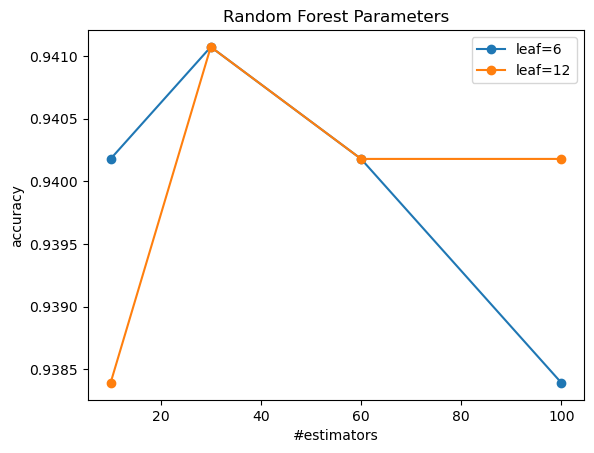

In [101]:
#results from grid search
rf_results = pd.DataFrame(grid_search_rf.cv_results_)

rf_results["param_n_estimators"] = rf_results["param_n_estimators"].astype(int)
rf_results["param_max_leaf_nodes"] = rf_results["param_max_leaf_nodes"].astype(int)
# unique values
leaf_values = list(rf_results["param_max_leaf_nodes"].unique())

plt.figure()
# loop through each leaf node
for leaf in leaf_values:
    x_vals = []
    y_vals = []
    
    for i in range(len(rf_results)):
        if rf_results["param_max_leaf_nodes"][i] == leaf:
            x_vals.append(rf_results["param_n_estimators"][i])
            y_vals.append(rf_results["mean_test_score"][i])
    plt.plot(x_vals, y_vals, marker='o', label="leaf=" + str(leaf))

plt.xlabel("#estimators")
plt.ylabel("accuracy")
plt.title("Random Forest Parameters")
plt.legend()
plt.show()

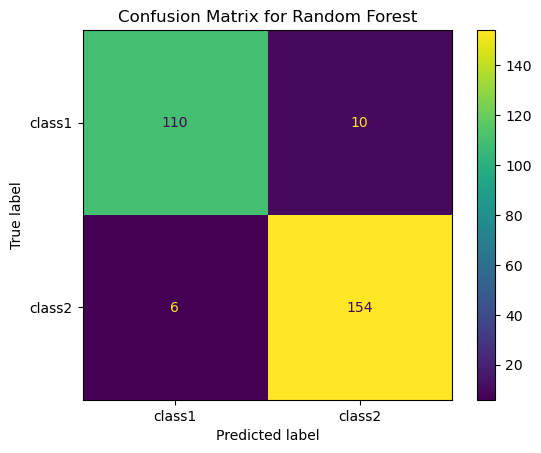

In [102]:
# Confusion matrix for Random Forest
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["class1", "class2"])
disp.plot()
plt.title("Confusion Matrix for Random Forest")
plt.show()

In [103]:
from sklearn import metrics

# Calculate actual and predicted labels for the test set
actual = y_test
predicted = best_rf_model.predict(X_test)

print("Classification Report for Random Forest:")
print(metrics.classification_report(actual, predicted, target_names=["class1", "class2"]))

print("\\nConfusion Matrix:")
print(metrics.confusion_matrix(actual, predicted))

Classification Report for Random Forest:
              precision    recall  f1-score   support

      class1       0.95      0.92      0.93       120
      class2       0.94      0.96      0.95       160

    accuracy                           0.94       280
   macro avg       0.94      0.94      0.94       280
weighted avg       0.94      0.94      0.94       280

\nConfusion Matrix:
[[110  10]
 [  6 154]]


In [104]:
from sklearn.svm import SVC
# SVM
# parameters you may consider
# C = [0.01, 0.1, 1, 5]
# gamma = [0.01, 0.1, 1, 10]
# optional
# kernel = []
param_grid_svm = {
    'C': [0.01, 0.1, 1, 5],
    'gamma': [0.01, 0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

svm = SVC(random_state=0)

grid_search_svm = GridSearchCV(
    estimator=svm,
    param_grid=param_grid_svm,
    cv=cvKFold,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_svm.fit(X_train, y_train)

best_c_svm = grid_search_svm.best_params_['C']
best_gamma_svm = grid_search_svm.best_params_['gamma']
best_kernel_svm = grid_search_svm.best_params_['kernel']
cv_accuracy_svm = grid_search_svm.best_score_

best_svm_model = grid_search_svm.best_estimator_
test_accuracy_svm = best_svm_model.score(X_test, y_test)

print(f"SVM best C: {best_c_svm}")
print(f"SVM best gamma: {best_gamma_svm}")
print(f"SVM best kernel: {best_kernel_svm}")
print(f"SVM cross-validation accuracy: {cv_accuracy_svm:.4f}")
print(f"SVM test set accuracy: {test_accuracy_svm:.4f}")

SVM best C: 5
SVM best gamma: 1
SVM best kernel: rbf
SVM cross-validation accuracy: 0.9429
SVM test set accuracy: 0.9321


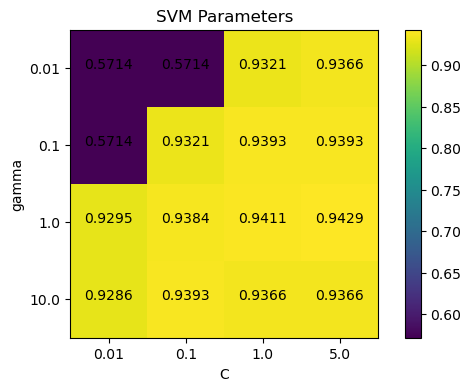

In [105]:
# graph for SVM hyperparameter tuning
# get results
svm_results = pd.DataFrame(grid_search_svm.cv_results_)
rbf_results = svm_results[svm_results["param_kernel"] == "rbf"]

# get unique values
c_values = sorted(rbf_results["param_C"].astype(float).unique())
gamma_values = sorted(rbf_results["param_gamma"].astype(float).unique())
pivot = rbf_results.pivot(
    index="param_gamma",
    columns="param_C",
    values="mean_test_score"
)

# graph
plt.figure(figsize=(7, 4))
plt.imshow(pivot)
plt.colorbar()

plt.xticks(range(len(c_values)), c_values)
plt.yticks(range(len(gamma_values)), gamma_values)
for i in range(len(gamma_values)):
    for j in range(len(c_values)):
        plt.text(j, i, round(pivot.iloc[i, j], 4), ha="center")

plt.xlabel("C")
plt.ylabel("gamma")
plt.title("SVM Parameters")

plt.show()

### Part 2: Results

Index(['Area', 'Perimiter', 'Major_Axis_Length', 'Minor_Axis_Length',
       'Eccentricity', 'Convex_Area', 'Extent'],
      dtype='object')


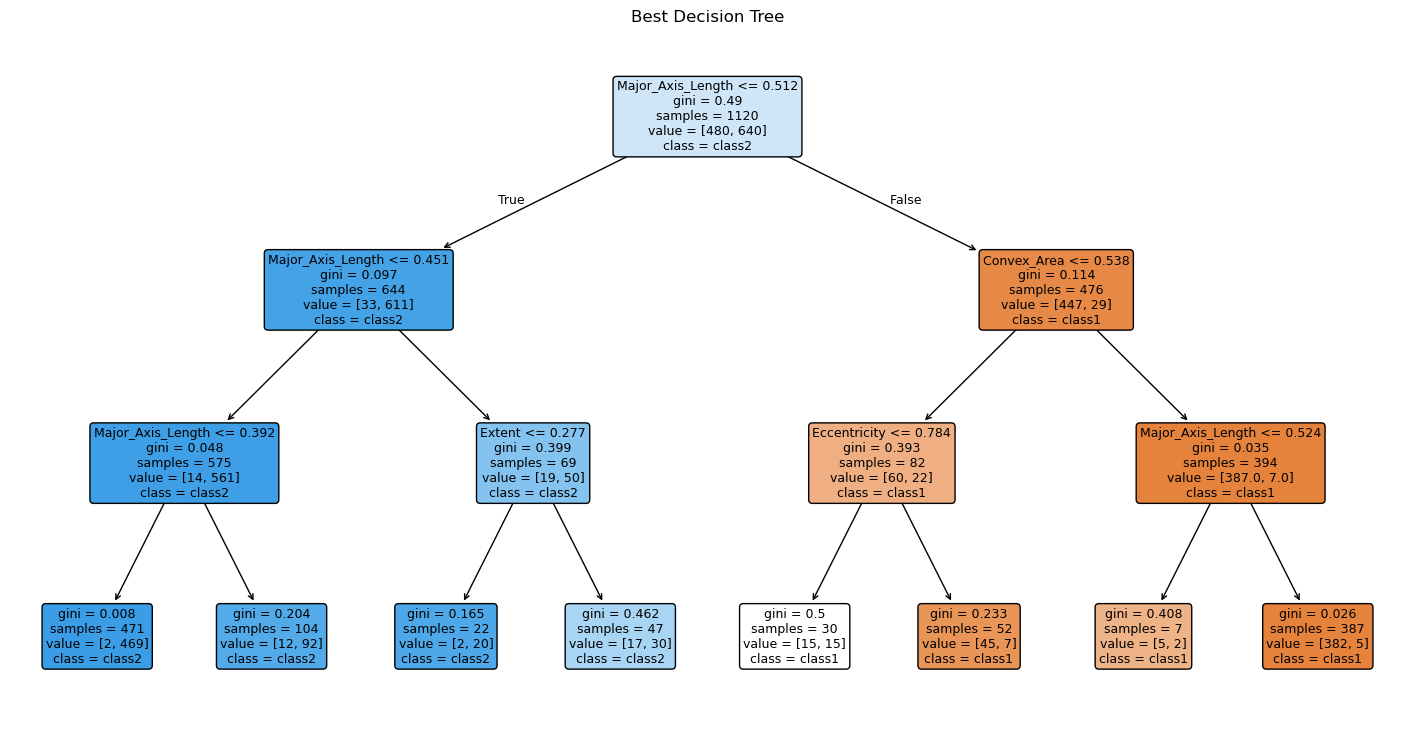

In [106]:
# graph for Best decision tree
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

print(feature_names)

plt.figure(figsize=(18, 9))
plot_tree(
    best_dt_model,
    filled=True,
    feature_names=feature_names,
    class_names=["class1", "class2"],
    rounded=True,
    fontsize=9
)
plt.title("Best Decision Tree")
plt.show()

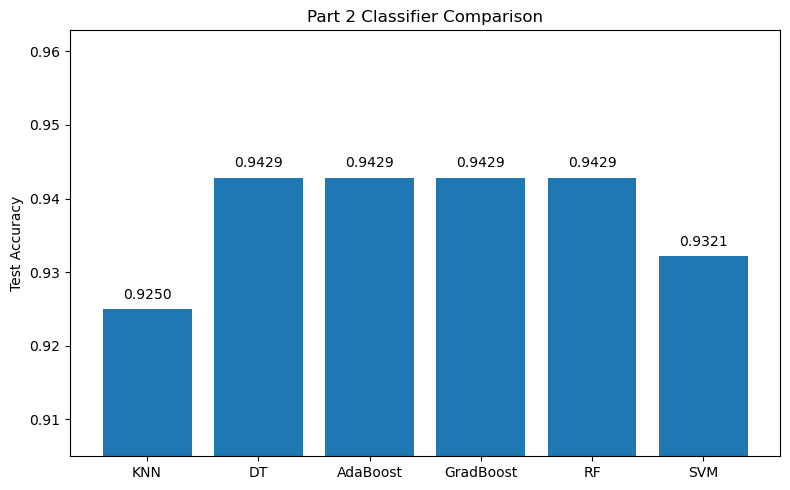

In [107]:
# graph for classifier comparison
import matplotlib.pyplot as plt

models = ["KNN", "DT", "AdaBoost", "GradBoost", "RF", "SVM"]
test_accuracies = [
    test_accuracy,
    test_accuracy_dt,
    test_accuracy_ada,
    test_accuracy_gb,
    test_accuracy_rf,
    test_accuracy_svm
]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, test_accuracies)

ymin = min(test_accuracies) - 0.02
ymax = max(test_accuracies) + 0.02
plt.ylim(ymin, ymax)

# add exact values
for bar, val in zip(bars, test_accuracies):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        val + 0.001,
        f"{val:.4f}",
        ha="center",
        va="bottom"
    )
plt.ylabel("Test Accuracy")
plt.title("Part 2 Classifier Comparison")

plt.tight_layout()
plt.show()

### Test your code

In [119]:
df_test = pd.read_csv("test-before.csv")


## **3. Reflection and Discussion**



In this study, several machine learning classifiers are applied to evaluate their performance on the given dataset after pre-processing, including K-Nearest Neighbors (KNN), Decision Tree, Random Forest, AdaBoost, Gradient Boosting, and Support Vector Machine (SVM). These models represent both simple and ensemble-based approaches to classification tasks.

KNN is a distance-based method that classifies samples based on their nearest neighbors,
making it simple but sensitive to parameter selection. Decision Tree is an interpretable model that splits data based on feature values, but it can suffer from overfitting. Ensemble methods such as Random Forest, AdaBoost, and Gradient Boosting combine multiple weak learners to improve prediction accuracy and reduce variance. SVM is a powerful model that aims to find
an optimal decision boundary, particularly effective in high-dimensional spaces but highly
dependent on hyperparameter tuning.

After tuning the hyperparameters of the three models used, each showed different results and
behavior with respect to their hyperparameter tuning. The first model (KNN, or K-Nearest
Neighbors) saw a marked improvement in performance due to changes made in the value of
“k” (the number of neighbors); accuracy improved significantly as the value of k increased
from an initial configuration of “k” at 1 up to an optimum value of around 7 through 10.
Maximum accuracy was reached when k was between .925 and .935; however, k=1 resulted
in the model performing worse than any of the others because of the excessive sensitivity of
the model to noise when k was small — resulting in high-variance predictions (overfitting).
Although accuracy can also improve as the value of k increases; high k values may cause the
model to smooth out or generalize to an excessive level (i.e., introducing bias). Therefore, it is
important to select an appropriate range for k in order to create a balance between accuracy
and bias.

For Random Forest, adjusting the number of trees and leaf size led to varying results. When
leaf=6, the model performed best with a medium-small number of trees (around 20–40 trees),
but performance dropped significantly when the number of trees increased to 100 trees.
Conversely, when leaf=12, the performance started lower but peaked around 40 trees, then
stabilized or slightly decreased. The overall accuracy of Random Forest fluctuated little
(around 0.9385 to 0.941), indicating sensitivity to the number of trees. However, beyond a
certain optimal range, increasing the number of trees did not significantly improve
performance.

Finally, for Support Vector Machine (SVM), adjusting C (regularization parameter) and
gamma (kernel coefficient) revealed the model’s high sensitivity to extreme values of both
parameters. When both C and gamma were very small, accuracy dropped significantly
(around 0.57). When C=1 and gamma=1, the accuracy reached its best or near-best (around
0.94). This indicates that SVM requires careful tuning of C and gamma to avoid overfitting or
underfitting.

Each model above has its respective pros and cons, depending on how they are applied. For
example, KNN works best as a classifier because it is commonly used for tasks like customer
segmentation and diagnosing diseases, and modifying k will adjust the model&#39;s sensitivity and
stability. Conversely, Random Forest can effectively process structured data (e.g., analyzing
customer behaviour or predicting finances), but accuracy and computation efficiency depend
on the number of trees used and the average size of the leaves in those trees. If a balance
between the highest accuracy and the least computational cost is desired, then you would
want to set leaf to 6 and the number of trees to fall into the medium range of trees (20–40
trees). As the complexity of the dataset increases, adding additional trees should improve your
predictive ability, however, if you add too many, you could incur needless computational
expense.

SVMs are usually applied on datasets that contain many features. Examples of such datasets
can be seen in industry when text is transformed into a numerical representation to classify it
or when images are transformed in the same manner for recognition purposes. C and gamma
values (hyperparameters) must be selected carefully, because their values can greatly affect
the model&#39;s ability to generalize beyond its training data. If C and gamma values are too low,
the model could miss capturing important patterns in the data set; consequently, it would lead
to a low accuracy score. If the values are at moderate levels like C=1 and gamma=1, the
model can perform at peak performance, particularly when using large and complex datasets.

Ensemble methods (Random Forest, AdaBoost, Gradient Boosting) provide a more
stable and consistent level of test accuracy (0.9429) than simpler models such as KNN
and Decision Tree. All three ensemble algorithms maintained their corresponding test
accuracy level of 0.9429, which is greater than the test accuracies of KNN (0.9357)
and SVM (0.9321). This demonstrates that ensemble methods typically achieve better
performance than other classifiers. By combining multiple learners, ensembles reduce
variance and improve generalisation.

Hyperparameter tuning, much like performance gain, has a substantial impact on
model performance across each of the four classifiers analysed. Overall,
hyperparameter tuning is significantly more impactful on classifiers (i.e KNN and
SVM), due to their high level of sensitivity/variability to hyperparameters, however,
ensemble classifiers appear to be more stable even with their default hyperparameter
settings. Therefore, it is reasonable to conclude that ensemble classifiers will continue
to maintain stable accuracy when hyperparameters are adjusted/changed.

The confusion matrix of the Random Forest classifier indicates that the majority of
the samples in the dataset were accurately classified into both classes with very few
samples misclassified in the other class. With the Random Forest model achieving a
test accuracy of 0.9429, this indicates that Random Forest should achieve comparable
test accuracies when tested on other unseen datasets.

Hyperparameters are important in determining how a model behaves and its
performance with different classifiers. For example, k in KNN will control the trade-
off of how biased or how variance a model has. A smaller k will classify incorrectly
as it will be overfit, and a larger k will classify incorrectly (over-smooth) than one that
is k=1. The number of trees and the number of leaves in a tree of Random Forest
controls how stable and how computationally efficient models are. More trees will
typically lead to improved performance until some maximum number of trees is
reached where the gain from additional trees is minor. For SVM, the regularization
parameter (C) and kernel coefficient (gamma) determine how flexible the decision
boundary is to mapping points to their respective classes. If either are set incorrectly,
the model may underfit or overfit. The research shows that responded differently
when hyperparameters changed, with some models being more sensitive and requiring
careful tuning for optimal performance than other models.

## **AI Acknowledgement**